## Test all profile results for data splits

The profiles are saved locally now in `/pscratch/sd/s/shengyu/tests/blinded_data` 

In [32]:
from pathlib import Path
import os
import re
import sys

# This notebook only loads/plots saved results; keep JAX from probing or reserving GPU memory.
os.environ.setdefault('JAX_PLATFORM_NAME', 'cpu')
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().resolve().parents[1]))

from desilike.samples import Profiles

from full_shape import tools
import full_shape.job_scripts.test_data_splits as tds


fits_dir = Path('/pscratch/sd/s/shengyu/tests')
project = 'blinded_data'
profile_root = fits_dir / project

stats_dir = Path('/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/data_splits')
version = 'data-dr2-v2'
covariance = 'holi-v3-altmtl'
cov_stats_dir = stats_dir
theory_model = 'folpsD'
cosmo_model = 'base'
prior_basis = 'physical_aap'
weight = 'default-FKP'

TRACERS = ['LRG1', 'LRG2', 'LRG3', 'QSO1']
REGIONS = ['GCcomb', 'NS', 'GCcomb_noN', 'GCcomb_noDES', 'NGC', 'SGC', 'N', 'NGCnoN', 'S', 'SGCnoDES']
STAT_SETS = ['S2-0.20', 'S2-0.25', 'S2-0.30', 'S2-0.20+S3-0.12']

COSMO_PARAMS = ['h', 'omega_cdm', 'omega_b', 'logA', 'n_s', 'H0', 'Omega_m', 'sigma8_m']
REGION_LABELS = {region: region for region in REGIONS}

tracers = TRACERS
regions = REGIONS

PROFILE_REQUESTS = [
    {'stats': ['mesh2_spectrum'], 'pk_kmax': 0.20, 'with_bk': False},
    {'stats': ['mesh2_spectrum'], 'pk_kmax': 0.25, 'with_bk': False},
    {'stats': ['mesh2_spectrum'], 'pk_kmax': 0.30, 'with_bk': False},
    {'stats': ['mesh2_spectrum', 'mesh3_spectrum'], 'pk_kmax': 0.20, 'with_bk': True},
]

DERIVE = False # derived H0, Omega_m, simga8

In [33]:
def make_kranges(pk_kmax=0.20, with_bk=False):
    kranges = {
        'mesh2_spectrum': [
            {'ells': 0, 'k': [0.02, pk_kmax, 0.005]},
            {'ells': 2, 'k': [0.02, pk_kmax, 0.005]},
        ],
    }
    if with_bk:
        kranges['mesh3_spectrum'] = [
            {'ells': (0, 0, 0), 'k': [0.02, 0.12, 0.005]},
            {'ells': (2, 0, 2), 'k': [0.02, 0.08, 0.005]},
        ]
    return kranges


def make_profile_key(tracer, region, stats, pk_kmax, with_bk=False):
    if with_bk:
        return f'{tracer}_{region}_S2+S3_{pk_kmax:.2f}+0.12'
    return f'{tracer}_{region}_S2_{pk_kmax:.2f}'


def _as_bestfit_dict(bestfit_choice):
    if hasattr(bestfit_choice, 'items'):
        return {str(key): value for key, value in bestfit_choice.items()}
    try:
        return {str(key): value for key, value in dict(bestfit_choice).items()}
    except Exception:
        pass
    params = bestfit_choice.params() if hasattr(bestfit_choice, 'params') else []
    values = np.asarray(bestfit_choice)
    return {str(param): value for param, value in zip(params, values)}


def _profile_error_value(profile, param):
    if 'error' not in profile:
        return np.nan
    try:
        err = profile.error[param]
    except Exception:
        return np.nan
    try:
        argmax = profile.bestfit.logposterior.argmax()
        err = np.asarray(err, dtype=float)
        err = err[argmax] if err.ndim else err.item()
    except Exception:
        err = np.asarray(err, dtype=float).item()
    return float(abs(err)) if np.isfinite(err) else np.nan


_SIGMA8_M_CACHE = {}
COMPUTE_SIGMA8_M_ERRORS = True

def _sigma8_cache_key(bestfit):
    values = []
    for name in ['h', 'omega_cdm', 'omega_b', 'logA', 'n_s']:
        value = bestfit.get(name, np.nan)
        values.append(round(float(value), 10) if np.isfinite(value) else None)
    return tuple(values)


def _sigma8_m_from_bestfit(bestfit):
    key = _sigma8_cache_key(bestfit)
    if key in _SIGMA8_M_CACHE:
        return _SIGMA8_M_CACHE[key]
    try:
        from cosmoprimo.fiducial import DESI
        params = {}
        for name in ['h', 'omega_cdm', 'omega_b', 'logA', 'n_s']:
            if name in bestfit and np.isfinite(bestfit[name]):
                params[name] = float(bestfit[name])
        cosmo = DESI().clone(**params)
        sigma8_m = float(cosmo.get_fourier().sigma8_z(of='delta_m', z=0.))
    except Exception:
        sigma8_m = np.nan
    _SIGMA8_M_CACHE[key] = sigma8_m
    return sigma8_m


def _finite_difference_error(fn, bestfit, varied_params, step_by_param):
    variance = 0.
    used = False
    for param in varied_params:
        step = step_by_param.get(param, np.nan)
        center = bestfit.get(param, np.nan)
        if not np.isfinite(step) or step <= 0 or not np.isfinite(center):
            continue
        plus = dict(bestfit)
        minus = dict(bestfit)
        plus[param] = center + step
        minus[param] = center - step
        fplus = fn(plus)
        fminus = fn(minus)
        if not np.isfinite(fplus) or not np.isfinite(fminus):
            continue
        deriv = (fplus - fminus) / (2. * step)
        variance += (deriv * step)**2
        used = True
    return float(np.sqrt(variance)) if used else np.nan


def _profile_fit_results(profile):
    """Return only parameters already stored in the profile best fit.

    This is intentionally cheap: no cosmoprimo calls and no derived
    parameters. Add H0/Omega_m/sigma8_m later with
    postprocess_derived_cosmo_results(...).
    """
    bestfit = _as_bestfit_dict(profile.bestfit.choice(input=True, index='argmax'))
    fit_results = {}
    for name, value in bestfit.items():
        try:
            value = float(value)
        except Exception:
            continue
        if not np.isfinite(value):
            continue
        name = str(name)
        fit_results[name] = value
        err = _profile_error_value(profile, name)
        if np.isfinite(err):
            fit_results[f'{name}_err'] = float(err)
    return fit_results


def _derived_cosmo_results(fit_results, compute_sigma8_m=True, compute_sigma8_m_errors=False):
    h = fit_results.get('h', np.nan)
    omega_cdm = fit_results.get('omega_cdm', np.nan)
    omega_b = fit_results.get('omega_b', np.nan)

    h0 = 100. * h if np.isfinite(h) else np.nan
    omega_m = (omega_cdm + omega_b) / h**2 if np.isfinite(h) and h != 0 and np.isfinite(omega_cdm) and np.isfinite(omega_b) else np.nan

    h_err = fit_results.get('h_err', np.nan)
    omega_cdm_err = fit_results.get('omega_cdm_err', np.nan)
    omega_b_err = fit_results.get('omega_b_err', np.nan)
    logA_err = fit_results.get('logA_err', np.nan)
    n_s_err = fit_results.get('n_s_err', np.nan)

    h0_err = 100. * h_err if np.isfinite(h_err) else np.nan
    if np.isfinite(omega_m) and np.isfinite(h) and h != 0:
        omega_m_var = 0.
        if np.isfinite(omega_cdm_err):
            omega_m_var += (omega_cdm_err / h**2)**2
        if np.isfinite(omega_b_err):
            omega_m_var += (omega_b_err / h**2)**2
        if np.isfinite(h_err):
            omega_m_var += (2. * omega_m * h_err / h)**2
        omega_m_err = float(np.sqrt(omega_m_var)) if omega_m_var > 0 else np.nan
    else:
        omega_m_err = np.nan

    sigma8_m = _sigma8_m_from_bestfit(fit_results) if compute_sigma8_m else np.nan
    if compute_sigma8_m and compute_sigma8_m_errors:
        step_by_param = {
            'h': h_err,
            'omega_cdm': omega_cdm_err,
            'omega_b': omega_b_err,
            'logA': logA_err,
            'n_s': n_s_err,
        }
        sigma8_m_err = _finite_difference_error(_sigma8_m_from_bestfit, fit_results, step_by_param, step_by_param)
    else:
        sigma8_m_err = np.nan

    return {
        'H0': float(h0) if np.isfinite(h0) else np.nan,
        'H0_err': float(h0_err) if np.isfinite(h0_err) else np.nan,
        'Omega_m': float(omega_m) if np.isfinite(omega_m) else np.nan,
        'Omega_m_err': float(omega_m_err) if np.isfinite(omega_m_err) else np.nan,
        'sigma8_m': float(sigma8_m) if np.isfinite(sigma8_m) else np.nan,
        'sigma8_m_err': float(sigma8_m_err) if np.isfinite(sigma8_m_err) else np.nan,
    }


def postprocess_derived_cosmo_results(profiles, compute_sigma8_m=True, compute_sigma8_m_errors=False, overwrite=True):
    """Add H0/Omega_m/sigma8_m to profiles_by_key[*]['fit_results'].

    Run this after loading profiles, when you are ready to pay for the
    sigma8_m conversion. H0 and Omega_m are cheap; sigma8_m calls cosmoprimo.
    """
    rows = []
    for key, entry in profiles.items():
        if not isinstance(entry, dict):
            continue
        fit_results = entry.setdefault('fit_results', {})
        if not overwrite and all(name in fit_results for name in ['H0', 'Omega_m', 'sigma8_m']):
            derived = {name: fit_results.get(name, np.nan) for name in ['H0', 'H0_err', 'Omega_m', 'Omega_m_err', 'sigma8_m', 'sigma8_m_err']}
        else:
            derived = _derived_cosmo_results(
                fit_results,
                compute_sigma8_m=compute_sigma8_m,
                compute_sigma8_m_errors=compute_sigma8_m_errors,
            )
            fit_results.update(derived)
        rows.append({'key': key, **derived})
    return pd.DataFrame(rows)

def _profile_from_entry(entry):
    return entry['profile'] if isinstance(entry, dict) and 'profile' in entry else entry

In [34]:

profiles_by_key = {}
profile_paths_by_key = {}
profile_metadata_by_key = {}
missing_profile_paths = []

for request in PROFILE_REQUESTS:
    stats = request['stats']
    pk_kmax = request['pk_kmax']
    with_bk = request['with_bk']
    tds.KRANGES = make_kranges(pk_kmax=pk_kmax, with_bk=with_bk)
    for tracer in tracers:
        for region in regions:
            options = tds._build_run_options(
                stats=stats,
                tracers=[tracer],
                regions=[region],
                version=version,
                covariance=covariance,
                stats_dir=stats_dir,
                project=project,
                theory_model=theory_model,
                cov_stats_dir=cov_stats_dir,
                cosmo_model=cosmo_model,
                prior_basis=prior_basis,
                weight=weight,
            )
            profile_fn = tools.get_fits_fn(kind='profiles', fits_dir=fits_dir, project=project, **options)
            key = make_profile_key(tracer, region, stats, pk_kmax, with_bk=with_bk)
            profile_paths_by_key[key] = profile_fn
            profile_metadata_by_key[key] = {
                'tracer': tracer,
                'region': region,
                'stats': '+'.join(stats),
                'pk_kmax': pk_kmax,
                'bk_kmax': 0.12 if with_bk else np.nan,
                'fit_type': 'pk+bk' if with_bk else 'pk',
            }
            if not profile_fn.exists():
                missing_profile_paths.append({**profile_metadata_by_key[key], 'key': key, 'profile_fn': profile_fn})
                continue
            profile = Profiles.load(profile_fn)
            profiles_by_key[key] = {
                'profile': profile,
                'fit_results': _profile_fit_results(profile),
            }

print(f'Loaded {len(profiles_by_key)} profiles into profiles_by_key.')
print(f'Missing {len(missing_profile_paths)} requested profile files.')
if missing_profile_paths:
    display(pd.DataFrame(missing_profile_paths))

# Example lookup:
# profiles_by_key['LRG1_GCcomb_S2_0.20']['fit_results']
# profiles_by_key['LRG2_GCcomb_S2+S3_0.20+0.12']['profile']

[001331.32] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG1_GCcomb-S2-0.20-1aeb2c64/profiles.npy.
[001331.34] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG1_NS-S2-0.20-6958ff06/profiles.npy.
[001331.36] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG1_GCcomb_noN-S2-0.20-4440ad99/profiles.npy.
[001331.37] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG1_GCcomb_noDES-S2-0.20-1dbd0e45/profiles.npy.
[001331.38] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG1_NGC-S2-0.20-8ecb61af/profiles.npy.
[001331.39] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG1_SGC-S2-0.20-d75

[001331.51] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG2_N-S2-0.20-183aeae6/profiles.npy.
[001331.52] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG2_NGCnoN-S2-0.20-80ba28df/profiles.npy.
[001331.54] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG2_S-S2-0.20-be2ece99/profiles.npy.
[001331.56] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG2_SGCnoDES-S2-0.20-eaf46ce9/profiles.npy.
[001331.58] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG3_GCcomb-S2-0.20-cca5efd6/profiles.npy.
[001331.59] [0/1] 04-27 06:52  Profiles                  INFO     Loading /pscratch/sd/s/shengyu/tests/blinded_data/cosmo-base_LRG3_NS-S2-0.20-2e21bdca/profil

In [47]:
profiles_by_key['LRG3_GCcomb_S2_0.30']['fit_results']

{'h': 0.6860510047236293,
 'h_err': 0.013342896247958314,
 'omega_cdm': 0.12493643602097815,
 'omega_cdm_err': 0.012748232287078713,
 'omega_b': 0.022378205174908235,
 'omega_b_err': 0.00036845163603078707,
 'logA': 2.8277660883815923,
 'logA_err': 0.19134184748462313,
 'n_s': 0.8188305620125279,
 'n_s_err': 0.0709029125025481,
 'LRG3.b1p': 1.0896546731681278,
 'LRG3.b1p_err': 0.0919446503076013,
 'LRG3.b2p': -0.24788327662852463,
 'LRG3.b2p_err': 0.46686818070610875,
 'LRG3.bsp': -0.20360066893590256,
 'LRG3.bsp_err': 0.08503102212345717,
 'LRG3.X_FoG_pp': 1.0941825578255804,
 'LRG3.X_FoG_pp_err': 0.5768701309668138,
 'tau_reio': 0.0544,
 'm_ncdm': 0.059999919304831895,
 'N_eff': 3.045998221453431,
 'w0_fld': -1.0,
 'wa_fld': 0.0,
 'Omega_k': 0.0,
 'LRG3.b3p': 0.0,
 'LRG3.ctp': 0.0,
 'LRG3.alpha0p': 1.8010955317814326,
 'LRG3.alpha2p': -4.331570050295984,
 'LRG3.alpha4p': -2.690014521192615,
 'LRG3.sn0p': 0.01816033411942231,
 'LRG3.sn2p': -0.23826732301828202}

In [36]:
# Postprocess derived cosmology if needed, will take a while.
# H0 and Omega_m are cheap; sigma8_m calls cosmoprimo once per unique best fit.
if DERIVE:
    derived_cosmo = postprocess_derived_cosmo_results(
        profiles_by_key,
        compute_sigma8_m=True,
        compute_sigma8_m_errors=False,
    )
    display(derived_cosmo.head())

# After this, each entry has the extra keys in fit_results, e.g.
# profiles_by_key['QSO1_GCcomb_S2_0.20']['fit_results']

In [37]:
profile_index = pd.DataFrame([
    {'key': key, 'profile_fn': profile_paths_by_key[key], 'loaded': key in profiles_by_key, **metadata}
    for key, metadata in profile_metadata_by_key.items()
])
if len(profile_index):
    profile_index['tracer'] = pd.Categorical(profile_index['tracer'], TRACERS, ordered=True)
    profile_index['region'] = pd.Categorical(profile_index['region'], REGIONS, ordered=True)
    profile_index['stat_set'] = np.where(
        profile_index['fit_type'] == 'pk+bk',
        profile_index['pk_kmax'].map(lambda value: f'S2-{value:.2f}+S3-0.12'),
        profile_index['pk_kmax'].map(lambda value: f'S2-{value:.2f}'),
    )
    profile_index['stat_set'] = pd.Categorical(profile_index['stat_set'], STAT_SETS, ordered=True)
    profile_index = profile_index.sort_values(['tracer', 'region', 'stat_set']).reset_index(drop=True)

In [ ]:
bestfit_rows = []
failed_loads = []
for key, profile_entry in profiles_by_key.items():
    profile = _profile_from_entry(profile_entry)
    fit_results = profile_entry.get('fit_results', {}) if isinstance(profile_entry, dict) else {}
    metadata = profile_metadata_by_key[key]
    try:
        bestfit = _as_bestfit_dict(profile.bestfit.choice(input=True, index='argmax'))
    except Exception as exc:
        failed_loads.append({**metadata, 'key': key, 'profile_fn': profile_paths_by_key[key], 'error': repr(exc)})
        continue
    stat_set = 'S2-{:.2f}+S3-0.12'.format(metadata['pk_kmax']) if metadata['fit_type'] == 'pk+bk' else 'S2-{:.2f}'.format(metadata['pk_kmax'])
    bestfit_rows.append({
        'key': key,
        'tracer': metadata['tracer'],
        'region': metadata['region'],
        'stat': metadata['stats'],
        'kmax': f"{metadata['pk_kmax']:.2f}+0.12" if metadata['fit_type'] == 'pk+bk' else f"{metadata['pk_kmax']:.2f}",
        'stat_set': stat_set,
        'fit_type': metadata['fit_type'],
        'profile_fn': profile_paths_by_key[key],
        **bestfit,
        **fit_results,
    })

bestfits = pd.DataFrame(bestfit_rows)
if len(bestfits):
    bestfits['tracer'] = pd.Categorical(bestfits['tracer'], TRACERS, ordered=True)
    bestfits['region'] = pd.Categorical(bestfits['region'], REGIONS, ordered=True)
    bestfits['stat_set'] = pd.Categorical(bestfits['stat_set'], STAT_SETS, ordered=True)
    bestfits = bestfits.sort_values(['tracer', 'region', 'stat_set']).reset_index(drop=True)

available_cosmo = [param for param in COSMO_PARAMS if param in bestfits.columns]

In [ ]:
import matplotlib.gridspec as gridspec

PARAM_LABELS = {
    'h': r'$h$',
    'omega_cdm': r'$\omega_{\rm cdm}$',
    'omega_b': r'$\omega_b$',
    'logA': r'$\log(10^{10} A_s)$',
    'n_s': r'$n_s$',
    'H0': r'$H_0$',
    'Omega_m': r'$\Omega_m$',
    'sigma8_m': r'$\sigma_8$',
}

COLOR_TRACERS = {
    'LRG1': 'tab:blue',
    'LRG2': 'tab:orange',
    'LRG3': 'tab:green',
    'QSO1': 'tab:red',
}

STAT_LABELS = {
    'S2_0.20': r'$P(k)$ $k_{\max}=0.20$',
    'S2_0.25': r'$P(k)$ $k_{\max}=0.25$',
    'S2_0.30': r'$P(k)$ $k_{\max}=0.30$',
    'S2+S3_0.20+0.12': r'$P(k)+B(k)$',
}

def _profile_error_xerr(profile_entry, param):
    if isinstance(profile_entry, dict):
        fit_results = profile_entry.get('fit_results', {})
        if f'{param}_err' in fit_results and np.isfinite(fit_results[f'{param}_err']):
            err = abs(float(fit_results[f'{param}_err']))
            return [[err], [err]]
        profile = _profile_from_entry(profile_entry)
    else:
        profile = profile_entry

    err = _profile_error_value(profile, param)
    if not np.isfinite(err):
        return None
    return [[abs(err)], [abs(err)]]

def plot_region_kmax_profile_comparison(
    param,
    regions=None,
    stat_suffixes=None,
    tracers=TRACERS,
    show_gc_band=True,
):
    if param not in bestfits.columns:
        raise ValueError(f'{param} is not in bestfits columns')

    nrows = len(stat_suffixes) * len(regions)
    fig = plt.figure(figsize=(2.35 * len(tracers), 0.22 * (nrows + len(stat_suffixes)) + 0.8))
    gs = gridspec.GridSpec(
        1, len(tracers),
        wspace=0.08, hspace=0.0,
        top=0.92, bottom=0.10, left=0.18, right=0.98,
    )

    y_positions = {}
    y_labels = []
    y = 0
    group_centers = {}
    group_bounds = []

    for stat_suffix in stat_suffixes:
        group_start = y
        for region in regions:
            y_positions[(stat_suffix, region)] = y
            y_labels.append(REGION_LABELS.get(region, region))
            y += 1
        group_end = y - 1
        group_centers[stat_suffix] = 0.5 * (group_start + group_end)
        group_bounds.append(group_end + 0.5)
        y += 1  # compact blank separator between kmax groups

    yticks = [y_positions[(stat_suffix, region)] for stat_suffix in stat_suffixes for region in regions]
    yticklabels = [REGION_LABELS.get(region, region) for stat_suffix in stat_suffixes for region in regions]

    for ind_col, tracer in enumerate(tracers):
        ax = fig.add_subplot(gs[0, ind_col])
        color = COLOR_TRACERS.get(tracer, f'C{ind_col}')
        ax.set_title(f'blinded {tracer}', fontsize=10)
        ax.set_xlabel(PARAM_LABELS.get(param, param), fontsize=12)
        # ax.grid(axis='x', alpha=0.20)

        if ind_col == 0:
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels, fontsize=8)
            trans = ax.get_yaxis_transform()
            for stat_suffix, yc in group_centers.items():
                ax.text(
                    -0.55, yc, STAT_LABELS.get(stat_suffix, stat_suffix),
                    transform=trans, ha='right', va='center', fontsize=8,
                )
        else:
            ax.set_yticks(yticks)
            ax.set_yticklabels([])

        # separators between kmax groups
        for boundary in group_bounds[:-1]:
            ax.axhline(boundary, color='0.85', lw=0.8, zorder=0)

        for stat_suffix in stat_suffixes:
            gc_interval = None

            for region in regions:
                yy = y_positions[(stat_suffix, region)]
                key = f'{tracer}_{region}_{stat_suffix}'
                if key not in profiles_by_key:
                    continue

                row = bestfits.loc[bestfits['key'] == key]
                if row.empty or pd.isna(row.iloc[0][param]):
                    continue
                center = float(row.iloc[0][param])
                xerr = _profile_error_xerr(profiles_by_key[key], param)
                ax.scatter(center, yy, edgecolors=color, facecolors='none', s=28, zorder=3)
                if xerr is not None:
                    ax.errorbar(center, yy, xerr=xerr, color=color, capsize=2, lw=1.0, zorder=2)
                    if region == 'GCcomb':
                        gc_interval = (center - xerr[0][0], center + xerr[1][0])
                elif region == 'GCcomb':
                    ax.axvline(center, color=color, alpha=0.15, lw=3, zorder=0)

            if show_gc_band and gc_interval is not None and stat_suffix == 'S2_0.20':
                ax.axvspan(*gc_interval, color=color, alpha=0.055, zorder=0)

        ax.set_ylim(y - 1.0, -1.0)
    return fig

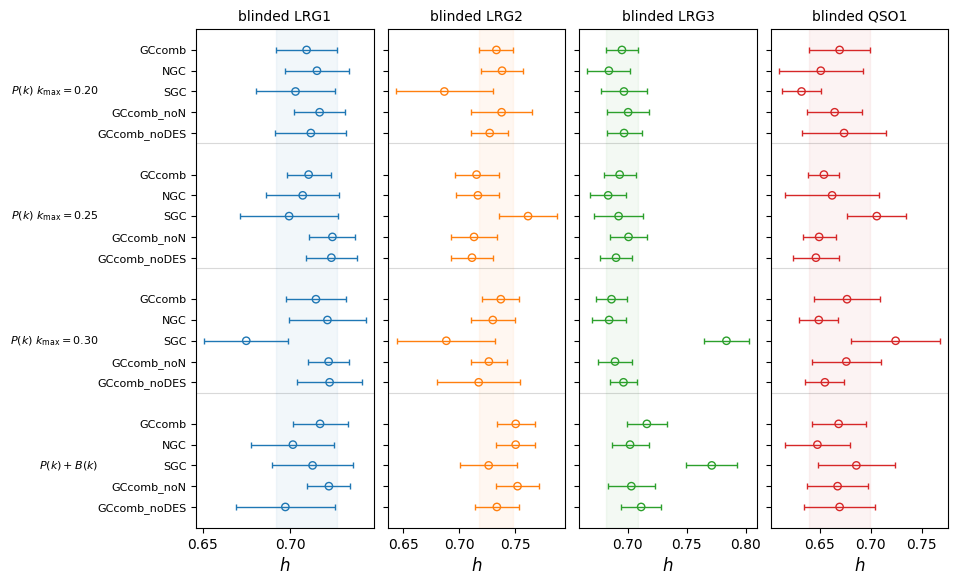

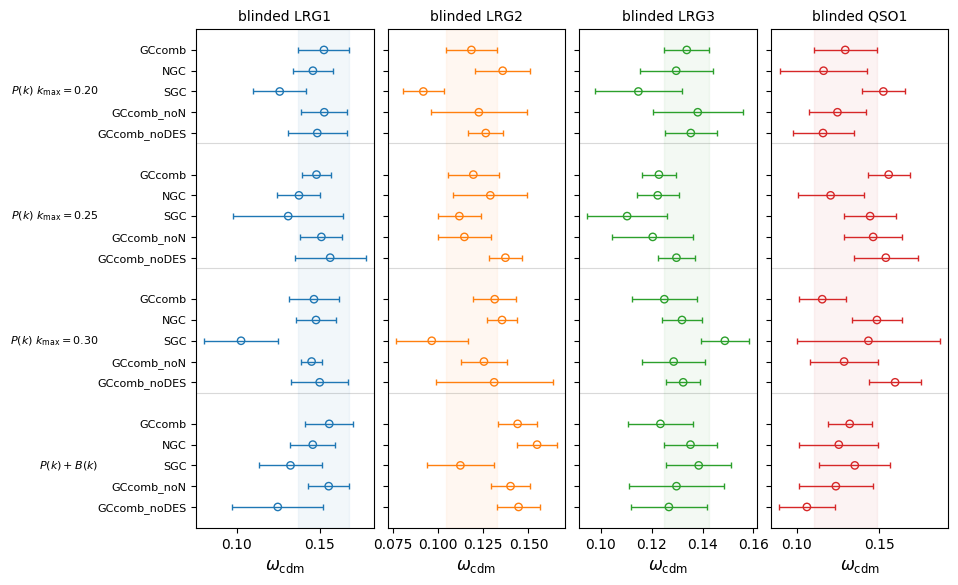

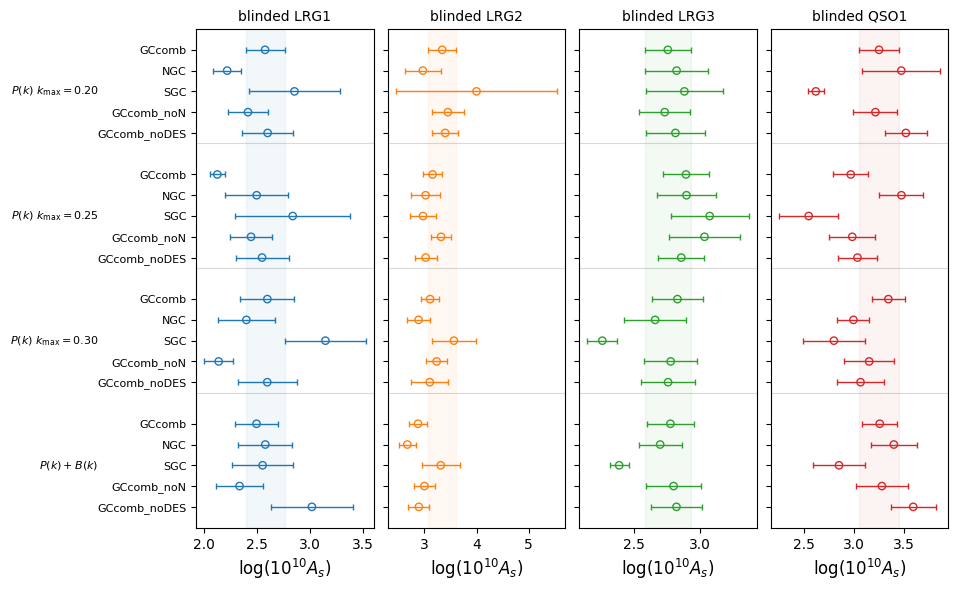

In [45]:
STAT_SUFFIXES = ['S2_0.20', 'S2_0.25', 'S2_0.30', 'S2+S3_0.20+0.12']
compare_regions = ['GCcomb', 'NGC', 'SGC', 'GCcomb_noN', 'GCcomb_noDES']
compare_params = ['h', 'omega_cdm', 'logA']

for param in compare_params:
    fig = plot_region_kmax_profile_comparison(param, regions=compare_regions, stat_suffixes=STAT_SUFFIXES)
    plt.show()